**Courtesy:**
https://pypi.org/project/gpax/#:~:text=GPax%20is%20a%20small%20Python,data%20reconstruction%20and%20active%20learning.

Installing and importing useful packages like 'numpyro', 'gpax', 'arviz' etc.

**Numpyro:** NumPyro is a probabilistic programming library for Python that is built on top of NumPy and PyTorch. Probabilistic programming allows us to express probabilistic models using a high-level syntax and then perform inference to learn about the hidden structure in the data.
**Gpax:** GPax is a small Python package for physics-based Gaussian processes (GPs) built on top of NumPyro and JAX. Its purpose is to take advantage of prior physical knowledge and different data modalities when using GPs for data reconstruction and active learning. (Courtesy:[gpax 0.1.1](https://pypi.org/project/gpax/#:~:text=GPax%20is%20a%20small%20Python,data%20reconstruction%20and%20active%20learning.) by Author: [ Maxim Ziatdinov](maxim.ziatdinov@ai4microcopy.com))           
**Arviz:** ArviZ is a Python library for exploratory analysis of Bayesian models. It is designed to work with probabilistic programming libraries such as PyMC3, PyStan, and others. ArviZ provides a set of tools for analyzing and visualizing the output of Bayesian models to help users better understand the results of their probabilistic models.




In [ ]:
import sys

# Step 1: Install gpjax (brings in numpyro, jax, etc.)
!{sys.executable} -m pip install -q gpjax

# Step 2: Patch numpyro's provenance.py for JAX 0.10.0 compatibility
# (xla_pmap_p was removed in JAX 0.10.0 but numpyro 0.20.1 still references it)
!sed -i 's/from jax.extend.core.primitives import call_p, closed_call_p, jit_p, xla_pmap_p/from jax.extend.core.primitives import call_p, closed_call_p, jit_p/' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

!sed -i 's/track_deps_rules\[xla_pmap_p\] = track_deps_call_rule//' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

print("Patch applied. Now restart your session, then import gpjax.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.5 MB/s eta 0:00:00
Patch applied. Now restart your session, then import gpjax.


In [ ]:
import gpjax
print(gpjax.__version__)  # Works with modern JAX
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import arviz as az
import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

0.13.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpyro
import arviz as az

import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
#import jax
import jax.numpy as jnp
#import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random, jacfwd, jacrev
from jax import lax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.infer import Predictive

import gpjax as gpx
from gpjax import kernels, mean_functions

import optax

import numpy as np
import scipy

print("JAX version:", jax.__version__)
print("NumPyro version:", numpyro.__version__)
print("GPJax version:", gpx.__version__)
print("Default backend:", jax.default_backend())


JAX version: 0.10.0
NumPyro version: 0.20.1
GPJax version: 0.13.6
Default backend: cpu


## **FORWARD MODELLING**
Generation of synthetic model of constant density contrast and synthetic gravity anomaly

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D*1000)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D*1000)**2)
    f1=np.arctan((x-A+(0.5*m))/(D*1000))-np.arctan((x-A-(0.5*m))/(D*1000))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D*1000)*f1)-(d*f2)+f3+f4
    g=2*G*rho*1000*f
    return g

In [ ]:
G = 6.67*(10**-6) #Gravitational constant in SI

D1= 0.3 #Lower end depth of the 1st prism in km
d1=0.001 #Upper end depth of the 1st prism in meter
m1=30.1 #width of the 1st prism in meter
rho1=2.7 #density of the 1st prism in gm/cc
A1= -50.1 #Co-ordinate of 1st prism in horizontal(X) direction

D2= 0.5 #Lower end depth of the 2nd prism in km
d2=0.001 #Upper end depth of the 2nd prism in meter
m2=30.1 #width of the 2nd prism in meter
rho2=2.2 #density of the 2nd prism in gm/cc
A2= 50.1 #Co-ordinate of 2nd prism in horizontal(X) direction

In [ ]:
#Defining "measure_func" function to calculate gravity anomaly in miligal with user defined station coordinates and above defined model parameters with some added random noise
def measure_func(x):
    return g_anomaly(x,A1,m1,D1,d1,rho1)+g_anomaly(x,A2,m2,D2,d2,rho2)

In [ ]:

NUM_INIT_POINTS = 50 # number of observation points

X = np.linspace(-75,75, NUM_INIT_POINTS) #Measurement points along the profile -75 meter to 75 meter
X_test = np.linspace(-75,75, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #Gravity anomaly in miligal at finer intervals with no addedcnoise

In [ ]:
import numpy as np
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
gaussian_noise = np.random.normal(0, 0.02, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.02, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.02 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.01 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.1)**2))+(b*((X*0.1)**3))+c)

#Adding noise to the gravity anomaly data

y = measure_func(X) + random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)
y_f=interp1d(X,y,'linear')
y_true=y_f(X_test)#interpolating between noisy observations at finer fintervals

*Plotting the synthetic model along with observed gravity anomaly*

[None, None, None, None, None, None]

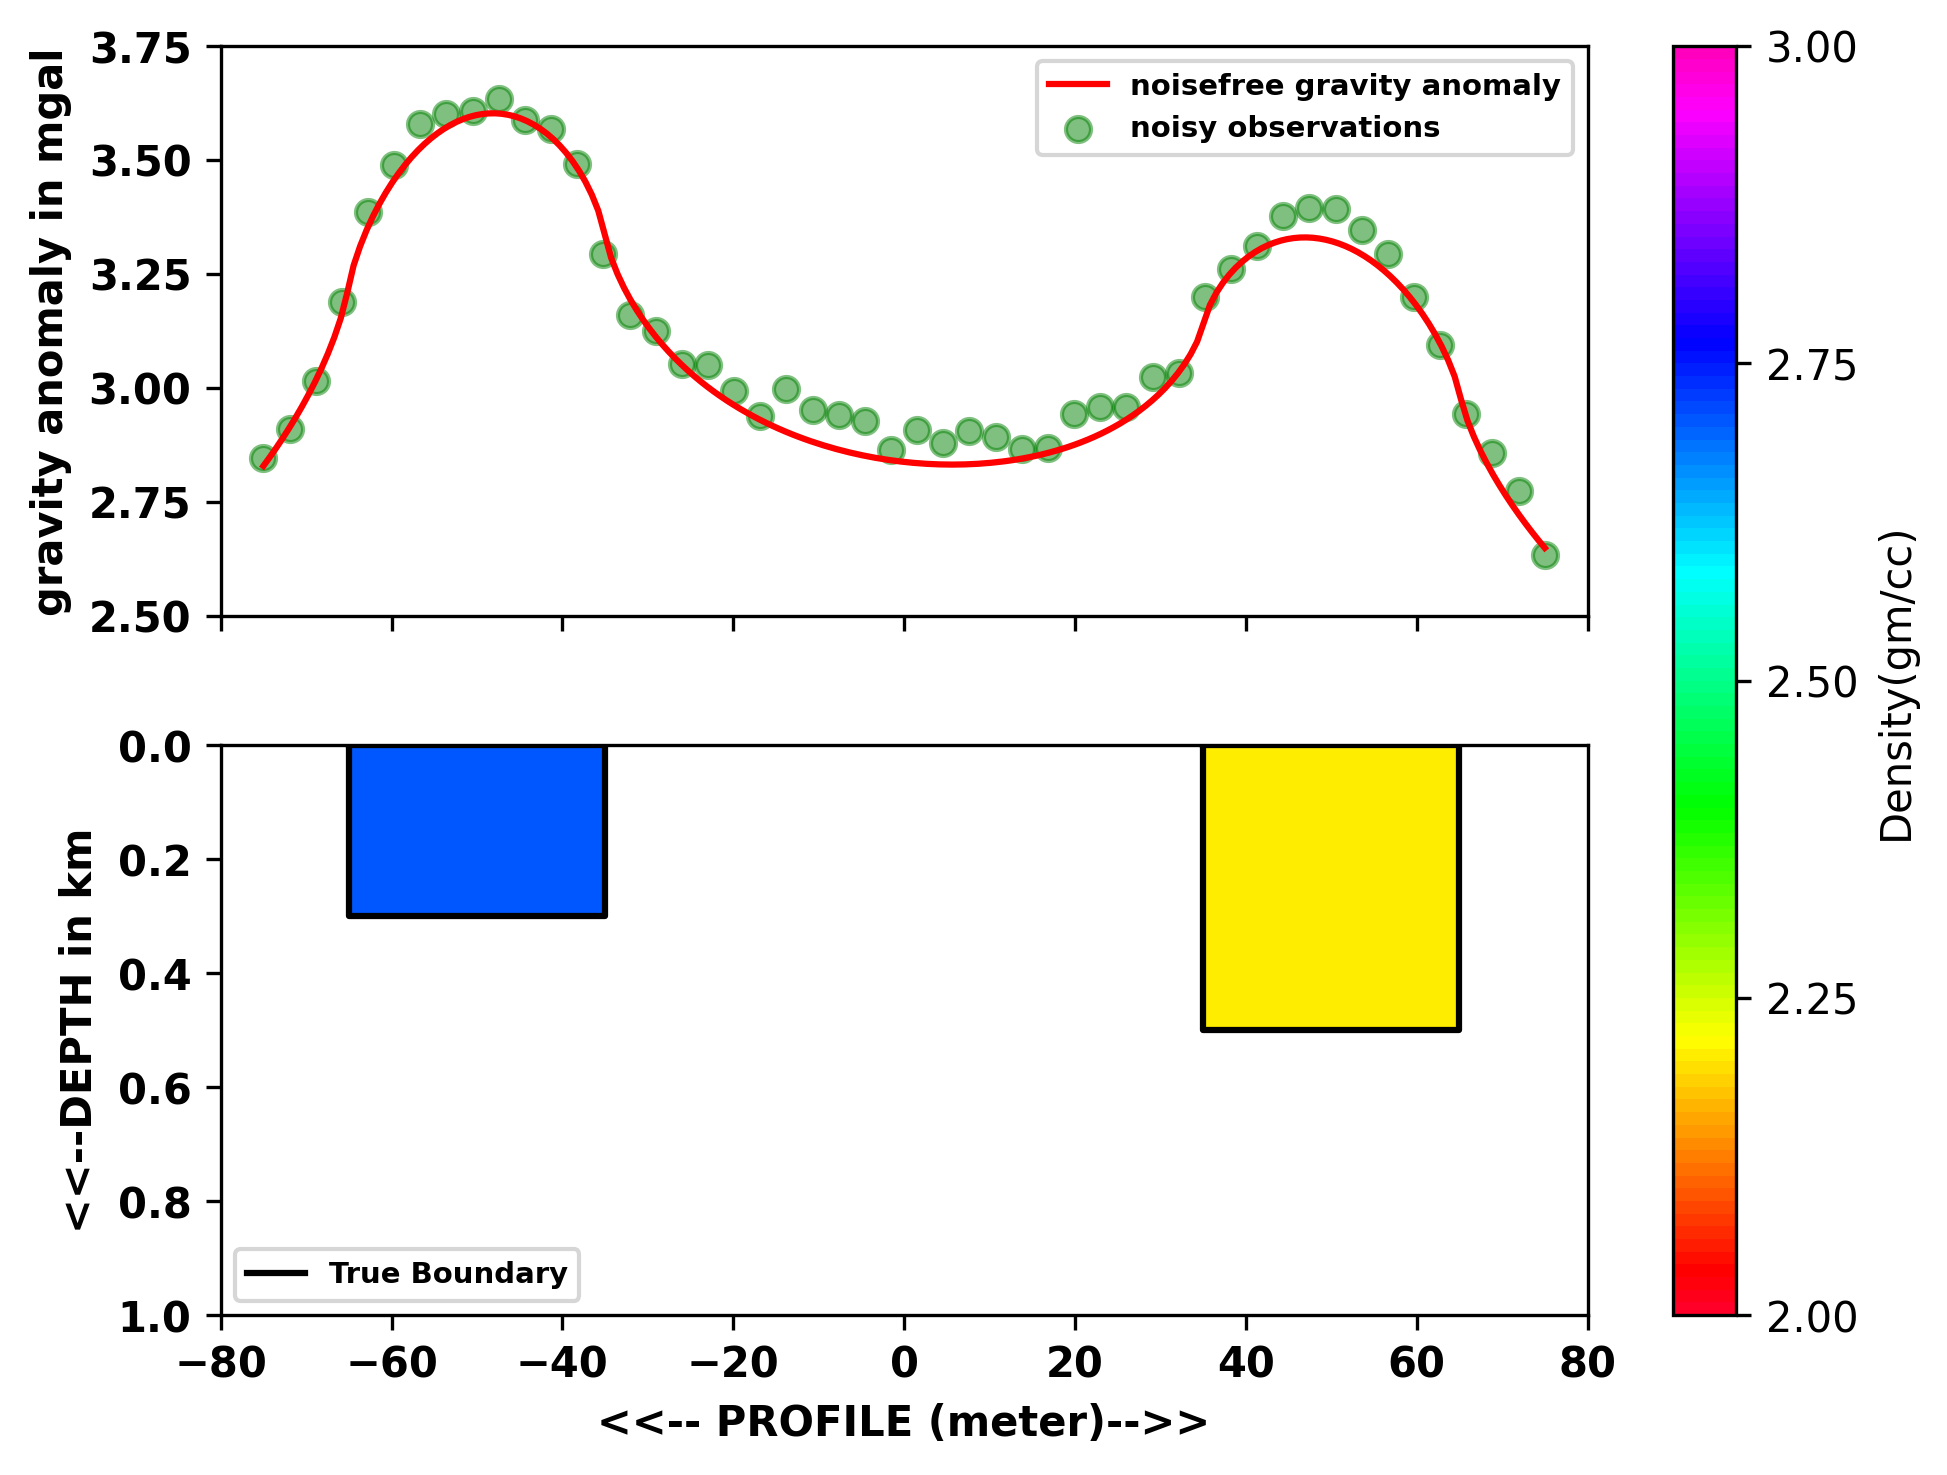

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

#import matplotlib.pyplot as plt
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3 #maximum density value in color scale in gm/cc
minimum_V=2 #minimum density value in color scale in gm/cc
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)#creating colorscale within the min to max range
#choosing the color depending upon the density value of 1st prism
index_value_V1 = (rho1-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
#choosing the color depending upon the density value of 2nd prism
index_value_V2 = (rho2-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting color scale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')

for i in range(1):
    #creating a prism using 4 corner co-ordinates
    coord1 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
    coord2 = [[35,0], [65,0], [65,0.5], [35,0.5]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values

    axs[1].plot(xs1,ys1,'k')#plotting prism1
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling the prism1 acc to its density value
    axs[1].plot(xs2,ys2,'k')#plotting prism2
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling the prism2 acc to its density value

    axs[1].set_xlim(-80,80)
    axs[1].set_ylim(1,0)
    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['True Boundary'],prop=legend_properties)
    axs[1].set_xlabel('<<-- PROFILE (meter)-->>',fontsize=10,weight='bold')
    axs[1].set_ylabel("<<--DEPTH in km",fontsize=10,weight='bold')
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')


#Plotting gravity anomaly
axs[0].plot(X_test, ground_truth, c='red') #noisefree anomaly
axs[0].scatter(X, y, alpha=0.5, c='g', marker='o') #observed data
axs[0].legend(['noisefree gravity anomaly','noisy observations'],prop=legend_properties)
axs[0].set_ylabel("gravity anomaly in mgal",fontsize=10,weight='bold')
axs[0].set_xlim(-80,80)
axs[0].set_ylim(2.5,3.75)
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[0].get_yticklabels(), weight='bold')

## **INVERSE MODELLING**

In [ ]:
from typing import Dict
import jax.numpy as jnp


In [ ]:
# CUSTOM MATERN KERNEL FOR v=3/2
def custom_Matern_kernel(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 3/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 3/2 formula
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1 + sqrt3 * D) * jnp.exp(-sqrt3 * D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

    # Example of a custom kernel prior for the above kernels
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """Custom priors for kernel hyperparameters."""
    import numpyro.distributions as dist
    k_scale = numpyro.sample("k_scale",dist.HalfNormal(1))
    k_length = numpyro.sample("k_length",dist.LogNormal(0,1))
    return {"k_length": k_length, "k_scale": k_scale}


In [ ]:
def gp_predict(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    """
    Returns:
        y_pred     : (n_draws, N_test) - posterior means per draw
        y_sampled  : (n_draws, N_test) - posterior predictive samples
        pred_mean  : (N_test,)         - mean over posterior draaws
        pred_std   : (N_test,)         - std over posterior draws
    """
    jitter = 1e-6

    # Ensure 2D
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means   = []
    all_samples = []

    for i in range(n_draws):
        # Extract posterior sample of kernel params
        k_scale   = samples["k_scale"][i]
        k_length  = samples["k_length"][i]
        noise_var = samples["noise_var"][i]

        # Build params dict for custom_Matern_kernel
        kernel_params = {
            "k_scale"  : k_scale,
            "k_length" : k_length
        }

        # Extract mean function params for this draw
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        # ── Use custom_Matern_kernel directly ──────────────────────
        # K(X_train, X_train)
        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)

        # K(X_test, X_train)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)

        # K(X_test, X_test)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])  # ensure PSD
        # ───────────────────────────────────────────────────────────

        # Posterior mean and covariance
        mean_train = Bayes_1_Inf(x_train_1d, mean_params_i)
        mean_test  = Bayes_1_Inf(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        # Posterior covariance
        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v
        cov_s += jitter * jnp.eye(X_test.shape[0])  # ensure PSD

        # Draw from posterior predictive
        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)

        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)  # (n_draws, N_test)
    y_pred    = jnp.stack(all_means)    # (n_draws, N_test)
    pred_mean = y_pred.mean(0)          # (N_test,)
    pred_std  = y_pred.std(0)           # (N_test,)

    return y_pred, y_sampled, pred_mean, pred_std

Defining Model and priors over parameters of the model (to make it probabilistic)

In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D*1000)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D*1000)**2)
    f1=jnp.arctan((x-A+(0.5*m))/(D*1000))-jnp.arctan((x-A-(0.5*m))/(D*1000))
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=((D*1000)*f1)-(d*f2)+f3+f4
    return 2*G*rho*1000*f

#Now defining a model Bayes_1_Inf() based on the prior knowledge of gravity anomaly generation for layers to use in the inversion.
def Bayes_1_Inf(x,params):
    G=6.67*(10**-6)
    B_D1 = params["B_D1"]
    density1 = params["density_1"]
    B_D2 = params["B_D2"]
    density2 = params["density_2"]
    v1=g_ano(x,A1,m1,B_D1,d1,density1)
    v2=g_ano(x,A2,m2,B_D2,d2,density2)
    u=v1+v2
    return u

In [ ]:
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
def Bayes_1_Inf_prior():
    return{
        "B_D1" : numpyro.sample("B_D1", numpyro.distributions.Uniform(0, 0.7)),
        "B_D2" : numpyro.sample("B_D2", numpyro.distributions.Uniform(0.2, 0.9)),
        "density_2" : numpyro.sample("density_2", numpyro.distributions.Uniform(2,3)),
        "density_1" : numpyro.sample("density_1", numpyro.distributions.Uniform(2,3))
    }

Running a 'structured' GP for the model. We have also keep in mind that, if we want to make our GP 'structured', we should pass the mean function (deterministic function) and mean function prior arguments to it at the initialization stage. If we define mean function as zero, we will revert to standard GP.

**STRUCTURED GP**

In [ ]:
def gp_model(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_1_Inf_prior()
    mean_vec    = Bayes_1_Inf(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)

# Run MCMC
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1 = MCMC(NUTS(gp_model), num_warmup=500, num_samples=100)
mcmc1.run(rng_key, X, y)
samples1 = mcmc1.get_samples()


sample: 100%|██████████| 600/600 [01:19<00:00,  7.51it/s, 63 steps of size 2.33e-02. acc. prob=0.86]


In [ ]:
params1 = mcmc1.get_samples()
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred1, y_sampled1, pred_mean1, pred_std1 = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)

#####
pred_mean1 = np.array(y_sampled1.mean(0))
pred_std1  = np.array(y_sampled1.std(0))

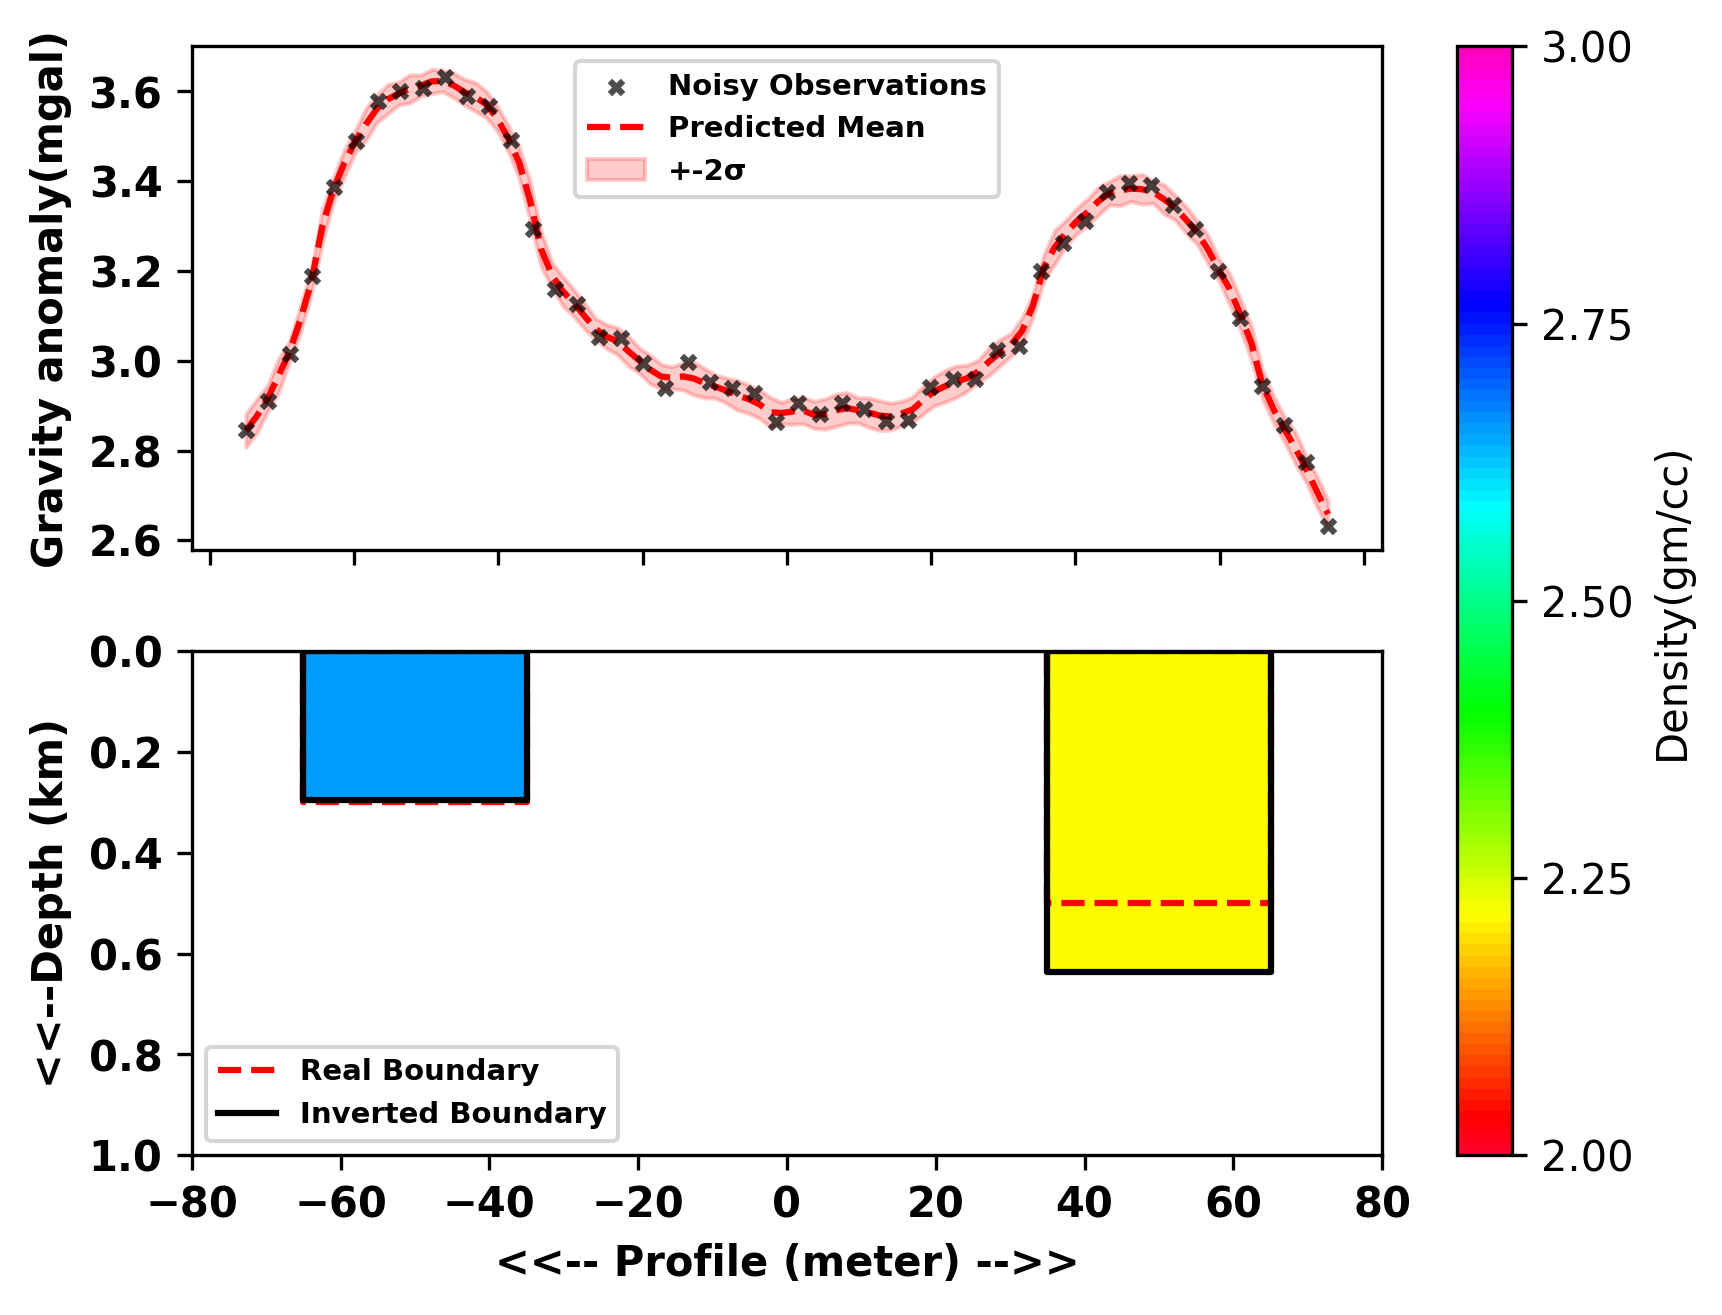

In [ ]:
fig, axs = plt.subplots(2)
fig.dpi=300
axs[0].set_ylabel("Gravity anomaly(mgal)",fontsize=10,weight='bold')
axs[0].scatter(X, y, marker='x',s=10, c='k', zorder=1, label="Noisy Observations", alpha=0.7)

axs[0].plot(X_test, pred_mean1, '--', c='red', label='Predicted Mean', zorder=0) #model reconstructions
axs[0].fill_between(X_test, pred_mean1 - 2*pred_std1 , pred_mean1 + 2*pred_std1 ,
                            color='r', alpha=0.2, label="+-2σ", zorder=0) #model uncertainty
axs[0].legend()
#axs[0].set_ylim(2.5,3.75)

cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3#maximum density value in color scale in gm/cc
minimum_V=2#minimum density value in color scale in gm/cc
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,1)
#choosing the color depending upon the inverted density value of 1st prism
index_value_V1 = (params1["density_1"].mean()-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
#choosing the color depending upon the inverted density value of 2nd prism
index_value_V2 = (params1["density_2"].mean()-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')#plotting colorscale
#creating a prism using 4 corner co-ordinates using inverted results
coord1 = [[-65,0], [-35,0], [-35,params1['B_D1'].mean()], [-65,params1['B_D1'].mean()]]
coord2 = [[35,0], [65,0], [65,params1['B_D2'].mean()], [35, params1['B_D2'].mean()]]
coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
xs1, ys1 = zip(*coord1) #create lists of x and y values
xs2, ys2 = zip(*coord2) #create lists of x and y values
#creating a prism using 4 corner co-ordinates using real values
coord3 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
coord4 = [[35,0], [65,0], [65,0.5], [35,0.5]]
coord3.append(coord3[0]) #repeat the first point to create a 'closed loop'
coord4.append(coord4[0]) #repeat the first point to create a 'closed loop'
xs3, ys3 = zip(*coord3) #create lists of x and y values
xs4, ys4 = zip(*coord4) #create lists of x and y values
axs[1].plot(xs3,ys3,'red',linestyle='dashed')#plotting prism1 using real values
axs[1].plot(xs1,ys1,'k')#plotting prism1 using inverted values
axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling inverted prism1 with inverted density value of prism 1
axs[1].plot(xs4,ys4,'red',linestyle='dashed')#plotting prism2 using real values
axs[1].plot(xs2,ys2,'k')#plotting prism2 using inverted values
axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling inverted prism1 with inverted density value of prism 2
axs[1].set_xlim(-80,80)
axs[1].set_ylim(1,0)
legend_properties = {'weight':'bold','size':'7'}
axs[1].legend(['Real Boundary','Inverted Boundary'],prop=legend_properties)
axs[0].legend(prop=legend_properties)
axs[1].set_xlabel('<<-- Profile (meter) -->>',fontsize=10,weight='bold')
axs[1].set_ylabel("<<--Depth (km)",fontsize=10,weight='bold')
#axs[1].set_xticks(weight='bold')
plt.setp(axs[1].get_xticklabels(), weight= 'bold')
plt.setp(axs[1].get_yticklabels(), weight= 'bold')
plt.setp(axs[0].get_xticklabels(), weight= 'bold',visible=False)
plt.setp(axs[0].get_yticklabels(), weight= 'bold')
plt.show()

***Simple active learning with STRUCTURED GP***

In [ ]:
#Choosing random values for initial points within a range(geologically & geophysically justified)
import random
INITIAL_DENSITY1 = random.uniform(2,3) #The density of geological rocks generally ranges from around 2 to 3 gm/cc
INITIAL_DEPTH1 = random.uniform(0,0.7) #Mostly gravity survey can provide information about top few hundred meters to a km of the subsurface
INITIAL_DENSITY2 =  random.uniform(2,3) #The density of geological rocks generally ranges from around 1.5 to 3.5 gm/cc
INITIAL_DEPTH2 = random.uniform(0.2,0.9) #Mostly gravity survey can provide information about top few hundred meters to a km of the subsurface

In [ ]:
PARAMS = {"B_D1": INITIAL_DEPTH1, "B_D2": INITIAL_DEPTH2, "density_1": INITIAL_DENSITY1,"density_2": INITIAL_DENSITY2} #Guessing some initial random values


Exploration step 1
Current number of observations: 50


sample: 100%|██████████| 2050/2050 [03:16<00:00, 10.45it/s, 111 steps of size 2.83e-02. acc. prob=0.83]



Posterior summary — step 1:
  Mean depth range: [0.3, 0.3] m
  Mean depth range: [0.6, 0.6] m

Next suggested point: x = -34.09 m
  Uncertainty at that point: 0.0224 mGal
  Measured value: 3.3343 mGal

Exploration step 2
Current number of observations: 51


sample: 100%|██████████| 2050/2050 [03:43<00:00,  9.16it/s, 383 steps of size 1.85e-02. acc. prob=0.87]



Posterior summary — step 2:
  Mean depth range: [0.3, 0.3] m
  Mean depth range: [0.6, 0.6] m

Next suggested point: x = -8.33 m
  Uncertainty at that point: 0.0209 mGal
  Measured value: 2.9476 mGal

Exploration step 3
Current number of observations: 52


...

sample: 100%|██████████| 2050/2050 [05:10<00:00,  6.60it/s, 127 steps of size 2.15e-02. acc. prob=0.77]



Posterior summary — step 4:
  Mean depth range: [0.3, 0.3] m
  Mean depth range: [0.6, 0.6] m

Next suggested point: x = 61.36 m
  Uncertainty at that point: 0.0197 mGal
  Measured value: 3.2188 mGal

Exploration step 5
Current number of observations: 54


sample: 100%|██████████| 2050/2050 [04:24<00:00,  7.75it/s, 63 steps of size 2.18e-02. acc. prob=0.79]



Posterior summary — step 5:
  Mean depth range: [0.5, 0.5] m
  Mean depth range: [0.4, 0.4] m

Next suggested point: x = -3.79 m
  Uncertainty at that point: 0.0237 mGal
  Measured value: 2.9430 mGal

Active learning complete.
Total observations: 55 (started with 50)

Running final MCMC on all observations...


sample: 100%|██████████| 2050/2050 [04:32<00:00,  7.52it/s, 223 steps of size 1.79e-02. acc. prob=0.86]


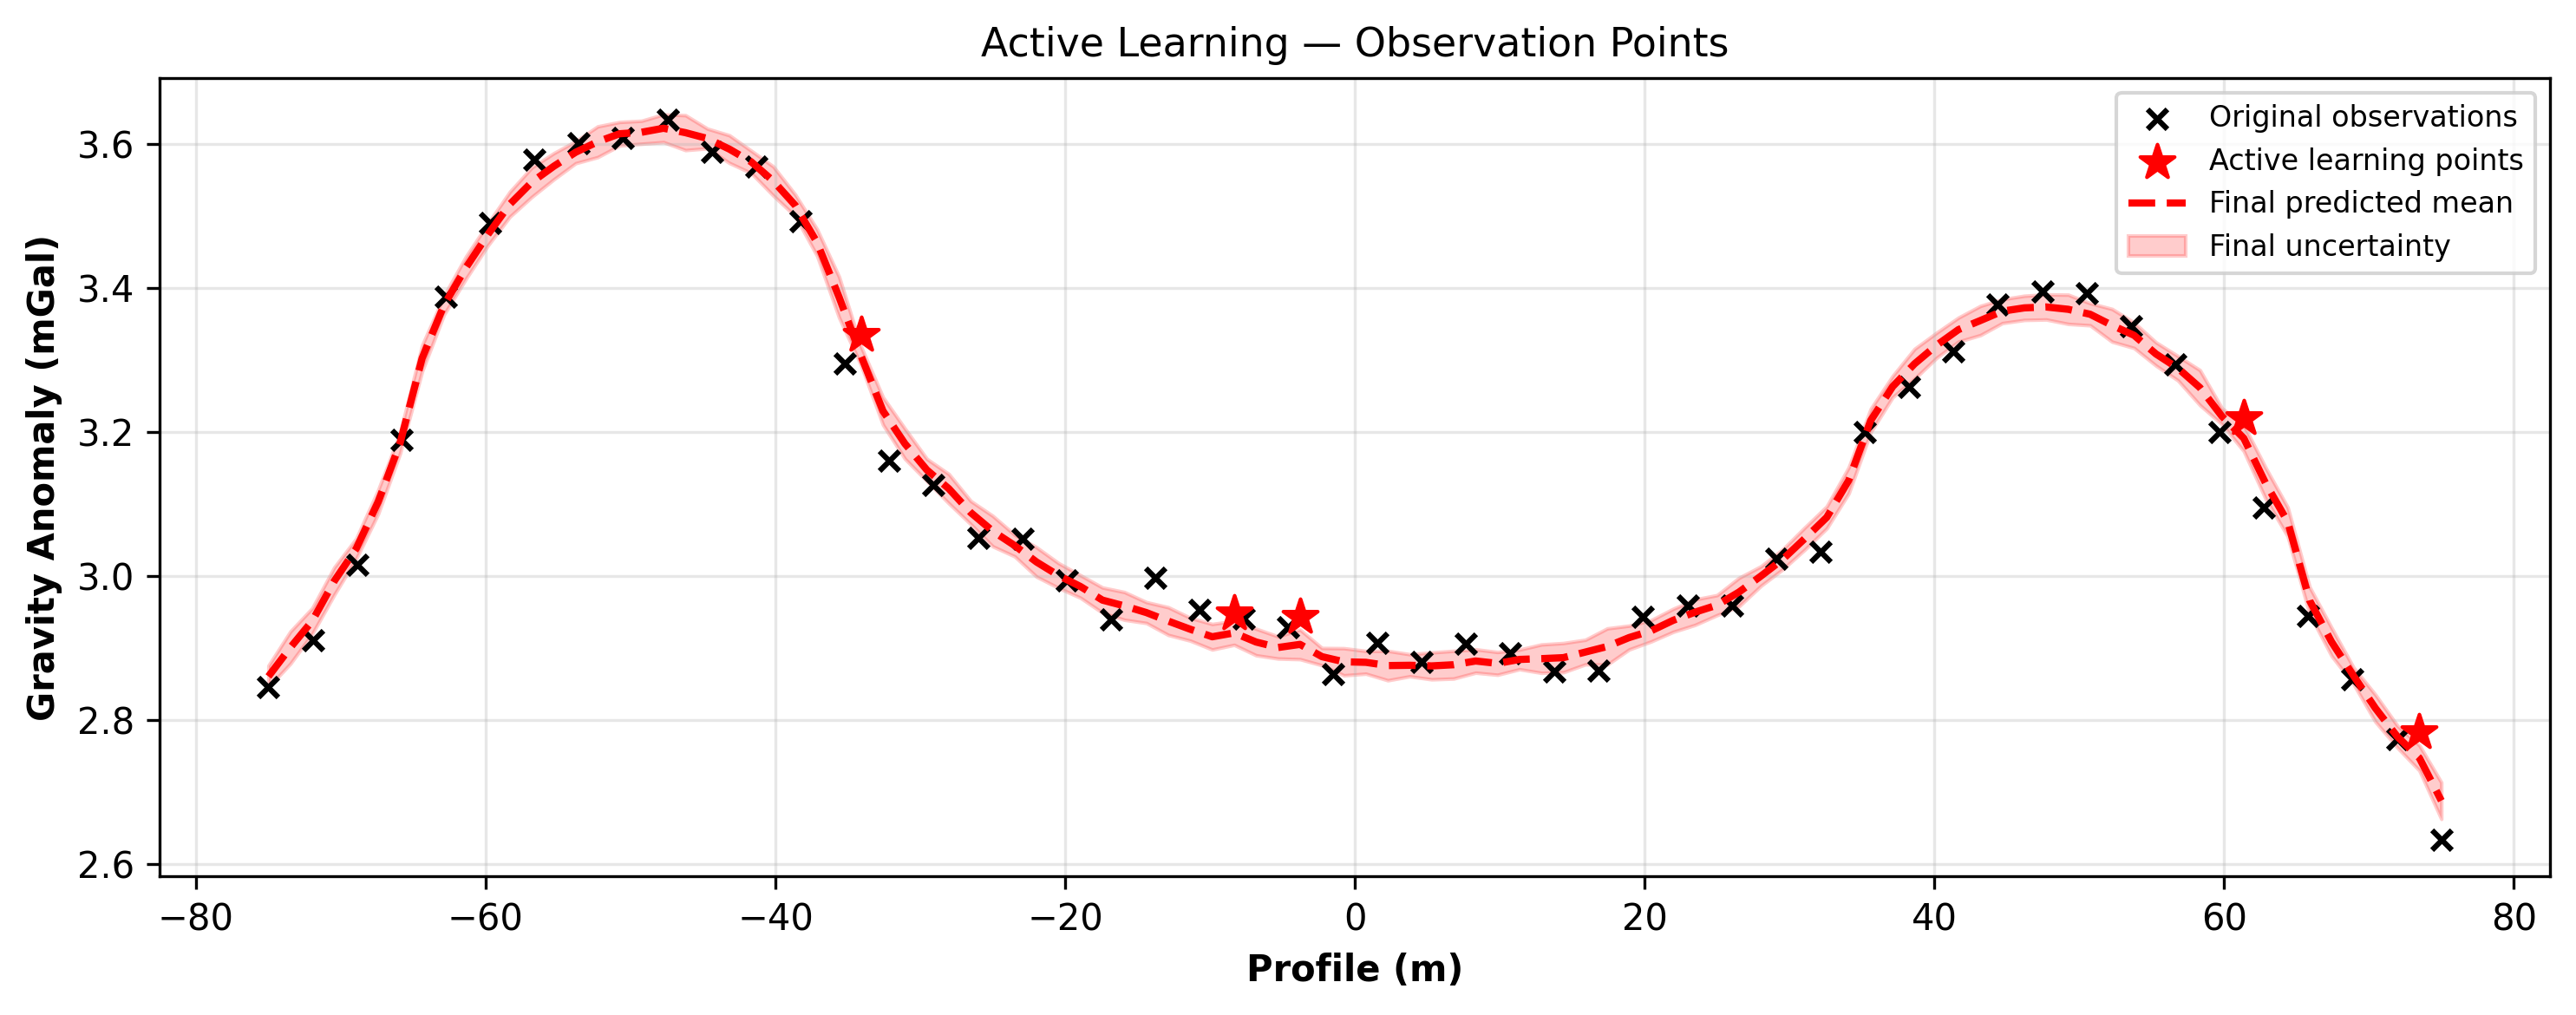

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", True)

# ── Initial setup (same as before) ──────────────────────────
SEED = 42
np.random.seed(SEED)
N_POLY_COEFFS=4
# Starting observations
Xo = np.array(X).flatten().copy()
yo = np.array(y).flatten().copy()

X_test_AL = np.linspace(-75, 75, 100)   # candidate points for active learning

# ── Uncertainty Exploration acquisition function ─────────────
def uncertainty_exploration(pred_std):
    """Returns index of point with highest posterior std."""
    return np.argmax(pred_std)


# ── Forward model at a single point (for active learning) ────
def forward_at_point(x_new, params_mean):
    """
    Evaluate the forward model at a single new x location
    using the posterior mean parameters.
    Used to generate a 'measurement' at the suggested point.
    """
    x_arr = jnp.array([x_new])
    return float(Bayes_1_Inf(x_arr, params_mean)[0])


# ── Active Learning Loop ─────────────────────────────────────
n_exploration_steps = 5   # same as your original

rng_key = jax.random.PRNGKey(SEED)
rng_key, rng_key_predict = jax.random.split(rng_key)

for step in range(n_exploration_steps):
    print(f"\n{'='*50}")
    print(f"Exploration step {step + 1}")
    print(f"{'='*50}")
    print(f"Current number of observations: {len(Xo)}")

    # ── Step 1: Fit GP model on current observations ─────────
    X_jnp = jnp.array(Xo).reshape(-1, 1)
    y_jnp = jnp.array(yo)

    mcmc_al = MCMC(
        NUTS(gp_model),
        num_warmup=2000,
        num_samples=50,
        num_chains=1,
        progress_bar=True
    )
    mcmc_al.run(rng_key, X_jnp, y_jnp)
    samples_al = mcmc_al.get_samples()

    # Print summary
    print(f"\nPosterior summary — step {step + 1}:")
    inverted_depths1_al = samples_al["B_D1"].mean()
    inverted_depths2_al = samples_al["B_D2"].mean()
    density1_al = samples_al["density_1"].mean()
    density2_al = samples_al["density_2"].mean()

    print(f"  Mean depth range: [{inverted_depths1_al.min():.1f}, {inverted_depths1_al.max():.1f}] m")
    print(f"  Mean depth range: [{inverted_depths2_al.min():.1f}, {inverted_depths2_al.max():.1f}] m")

    # ── Step 2: Predict over candidate points ─────────────────
    X_test_jnp = jnp.array(X_test_AL).reshape(-1, 1)

    _, y_sampled_al, pred_mean_al, pred_std_al = gp_predict(
        rng_key_predict, X_jnp, y_jnp, X_test_jnp, samples_al, n_samples=75
    )
    pred_mean_al = np.array(y_sampled_al.mean(0))
    pred_std_al  = np.array(y_sampled_al.std(0))

    # ── Step 3: Uncertainty Exploration — find next point ─────
    next_idx   = uncertainty_exploration(pred_std_al)
    next_point = X_test_AL[next_idx]
    print(f"\nNext suggested point: x = {next_point:.2f} m")
    print(f"  Uncertainty at that point: {pred_std_al[next_idx]:.4f} mGal")

    # ── Step 4: Generate 'measurement' at new point ───────────
    # Reconstruct posterior mean params for forward evaluation
    params_mean = {}
    params_mean[f"B_D1"] = samples_al["B_D1"].mean()
    params_mean[f"B_D2"] = samples_al["B_D2"].mean()
    params_mean[f"density_1"] = samples_al["density_1"].mean() # Changed key from 'density1' to 'density_1'
    params_mean[f"density_2"] = samples_al["density_2"].mean() # Changed key from 'density2' to 'density_2'

    # Evaluate forward model at new point + add noise (same noise model as original)
    y_new_clean = forward_at_point(next_point, params_mean)

    # Add same noise as original observations

    y_new = y_new_clean

    print(f"  Measured value: {y_new:.4f} mGal")

    # ── Step 5: Append new observation ───────────────────────
    Xo = np.append(Xo, next_point)
    yo = np.append(yo, y_new)

    # Update rng keys for next iteration
    rng_key, rng_key_predict = jax.random.split(rng_key)

print(f"\nActive learning complete.")
print(f"Total observations: {len(Xo)} (started with {len(np.array(X).flatten())})")




# ── Final full MCMC on all observations ──────────────────────
print("\nRunning final MCMC on all observations...")

X_final = jnp.array(Xo).reshape(-1, 1)
y_final = jnp.array(yo)

mcmc3 = MCMC(
    NUTS(gp_model),
    num_warmup=2000,
    num_samples=50,
    num_chains=1,
    progress_bar=True
)
mcmc3.run(rng_key, X_final, y_final)
samples3 = mcmc3.get_samples()
#####################################








################################################################
# ── Plot active learning progression ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.dpi = 300

original_X = np.array(X).flatten()
added_X    = Xo[len(original_X):]   # the points added during active learning

ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)
ax.scatter(added_X, yo[len(original_X):],
           marker='*', s=100, c='red', label='Active learning points', zorder=3)

# Plot final prediction
X_test_final_jnp = jnp.array(X_test_AL).reshape(-1, 1)
_, y_samp_f, pred_mean_f, pred_std_f = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp, samples3, n_samples=50
)
pred_mean_f = np.array(y_samp_f.mean(0))
pred_std_f  = np.array(y_samp_f.std(0))

ax.plot(X_test_AL, pred_mean_f, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL,
                pred_mean_f - pred_std_f,
                pred_mean_f + pred_std_f,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
ax.set_title("Active Learning — Observation Points", fontsize=11)
#ax.set_xlim(-5000, 5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("active_learning_progression.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

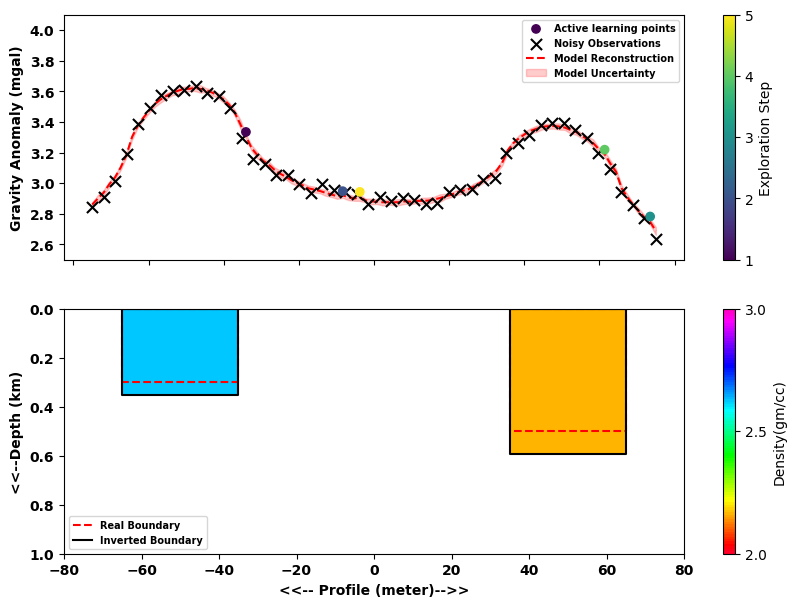

In [ ]:
#Collecting inverted model parameters
params4 = mcmc3.get_samples()
params4.keys()

import warnings
warnings.filterwarnings("ignore")

# Plot results

plt.tight_layout(pad=2)
plt.figure(figsize=(10, 7))
plt.subplot(211)
X_Seed=np.asarray(list(set(Xo).symmetric_difference(set(X))))
#y_Seed=measure_func(X_Seed)
y_Seed= np.asarray(list(set(yo).symmetric_difference(set(y))))
#plt.scatter(X_Seed, y_Seed,marker="D",label="New Discovered points", zorder=1)

plt.scatter(added_X, yo[len(original_X):],
           cmap='viridis',c=jnp.arange(1, len(X_Seed)+1), label='Active learning points', zorder=3)
#plt.scatter(Xo[50:], yo[50:],marker="D",label="New Discovered points", zorder=1)
#plt.scatter(Xo[50:], yo[50:], c=jnp.arange(1, len(Xo[50:])+1),
            #cmap='viridis', label="Sampled points", zorder=1)
cbar = plt.colorbar(label="Exploration Step")
cbar_ticks = np.arange(1, len(X_Seed) + 1, 1)
#cbar_ticks = np.arange(1, len(Xo[50:]) + 1, 1)
cbar.set_ticks(cbar_ticks)

plt.scatter(X, y, marker='x', s=64,
            c='k', label="Noisy Observations", zorder=1)
#plt.plot(X_test, truefunc, c='k', label='True function', zorder=0)
plt.plot(X_test, pred_mean_f, '--', c='red', label='Model Reconstruction', zorder=0) #model reconstructions

plt.fill_between(X_test, pred_mean_f - pred_std_f, pred_mean_f + pred_std_f,
                        color='r', alpha=0.2, label="Model Uncertainty", zorder=0) #model uncertainty

#plt.xlabel("X", fontsize=12)
plt.ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
plt.legend()
legend_properties = {'weight':'bold','size':'7'}
plt.legend(prop=legend_properties)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.tick_params(labelbottom=False)
plt.ylim(2.5,4.1)
#plt.show() # Remove this line to avoid creating a new figure


cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3#maximum density value in color scale in gm/cc
minimum_V=2#minimum density value in color scale in gm/cc
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)
#choosing the color depending upon the inverted density value of 1st prism
index_value_V1 = (params4['density_1'].mean()-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
#choosing the color depending upon the inverted density value of 2nd prism
index_value_V2 = (params4['density_2'].mean()-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)


plt.subplot(212) # Select the second subplot in the existing figure
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
# plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,3),label='Density(gm/cc)')
# Use the current axes (axs[1]) for the colorbar
plt.colorbar(sm, ax=plt.gca(), ticks=np.linspace(minimum_V, maximum_V, 3), label='Density(gm/cc)') # Changed line

#creating a prism using 4 corner co-ordinates using inverted results
coord1 = [[-65,0], [-35,0], [-35,params4['B_D1'].mean()], [-65,params4['B_D1'].mean()]]
coord2 = [[35,0], [65,0], [65,params4['B_D2'].mean()], [35, params4['B_D2'].mean()]]
coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
xs1, ys1 = zip(*coord1) #create lists of x and y values
xs2, ys2 = zip(*coord2) #create lists of x and y values
#creating a prism using 4 corner co-ordinates using real values
coord3 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
coord4 = [[35,0], [65,0], [65,0.5], [35,0.5]]
coord3.append(coord3[0]) #repeat the first point to create a 'closed loop'
coord4.append(coord4[0]) #repeat the first point to create a 'closed loop'
xs3, ys3 = zip(*coord3) #create lists of x and y values
xs4, ys4 = zip(*coord4) #create lists of x and y values
plt.plot(xs3,ys3,'red',linestyle='dashed')#plotting prism1 using real values
plt.plot(xs1,ys1,'k')#plotting prism1 using inverted values
plt.fill(xs1, ys1, facecolor=color_V1)#color filling inverted prism1 with inverted density value of prism 1
plt.plot(xs4,ys4,'red',linestyle='dashed')#plotting prism2 using real values
plt.plot(xs2,ys2,'k')#plotting prism2 using inverted values
plt.fill(xs2, ys2, facecolor=color_V2)#color filling inverted prism1 with inverted density value of prism 2
plt.xlim(-80,80)
plt.ylim(1,0)
legend_properties = {'weight':'bold','size':'7'}
plt.legend(['Real Boundary','Inverted Boundary'],prop=legend_properties)
plt.xlabel('<<-- Profile (meter)-->>',fontsize=10,weight='bold')
plt.ylabel("<<--Depth (km)",fontsize=10,weight='bold')
#axs[1].set_xticks(weight='bold')
plt.xticks(weight= 'bold')
plt.yticks(weight= 'bold')
plt.show()


**BAYESIAN OPTIMIZATION with STRUCTURED GP**


Exploration step 1


sample: 100%|██████████| 2500/2500 [00:25<00:00, 97.88it/s, 3 steps of size 2.55e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.37      0.16      0.35      0.15      0.65    240.80      1.00
       B_D2      0.51      0.21      0.49      0.20      0.83    424.08      1.00
  density_1      2.74      0.19      2.76      2.47      3.00    430.55      1.00
  density_2      2.26      0.17      2.24      2.00      2.49    468.33      1.00
k_length[0]     80.08     49.09     67.71     26.93    128.09    198.98      1.01
    k_scale      0.21      0.22      0.13      0.01      0.48    173.47      1.02
      noise      0.00      0.00      0.00      0.00      0.00    332.80      1.00

-48.618090452261306
2.3180944315707155


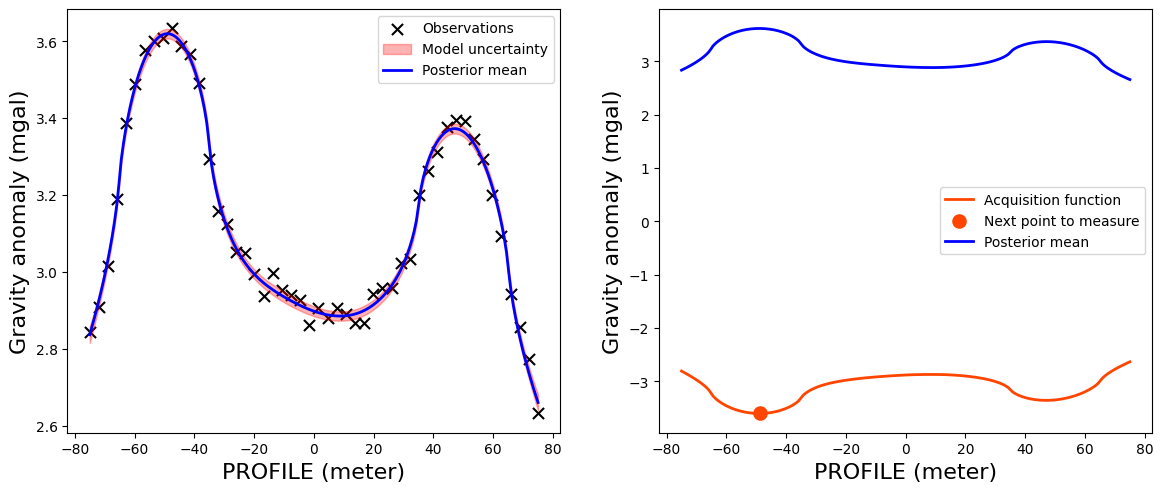


Exploration step 2


sample: 100%|██████████| 2500/2500 [00:51<00:00, 48.20it/s, 15 steps of size 1.02e-01. acc. prob=0.84]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.44      0.15      0.45      0.22      0.68    201.16      1.01
       B_D2      0.57      0.20      0.58      0.30      0.90    137.50      1.03
  density_1      2.45      0.20      2.44      2.14      2.77    129.03      1.00
  density_2      2.21      0.16      2.17      2.00      2.43    180.89      1.00
k_length[0]      6.58     19.26      0.55      0.06     19.37     63.53      1.00
    k_scale      0.04      0.06      0.02      0.01      0.06    103.56      1.00
      noise      0.03      0.01      0.03      0.01      0.05     98.99      1.00

-47.11055276381909
2.3112066573428773


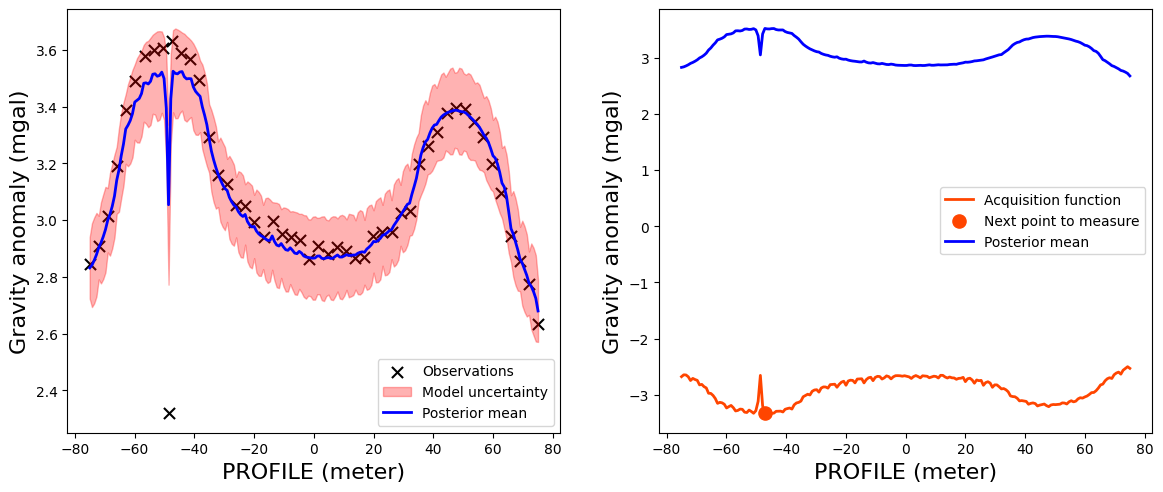


Exploration step 3


sample: 100%|██████████| 2500/2500 [00:53<00:00, 46.88it/s, 31 steps of size 9.08e-02. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.43      0.16      0.44      0.19      0.69    280.36      1.00
       B_D2      0.57      0.20      0.59      0.24      0.86    258.86      1.00
  density_1      2.37      0.22      2.34      2.04      2.71    229.01      1.00
  density_2      2.29      0.21      2.24      2.00      2.60    262.91      1.00
k_length[0]      3.90      9.87      0.76      0.02      8.21     99.31      1.00
    k_scale      0.05      0.06      0.03      0.01      0.07    115.26      1.00
      noise      0.06      0.02      0.05      0.02      0.08    220.19      1.00

-41.08040201005025
2.2698052738143524


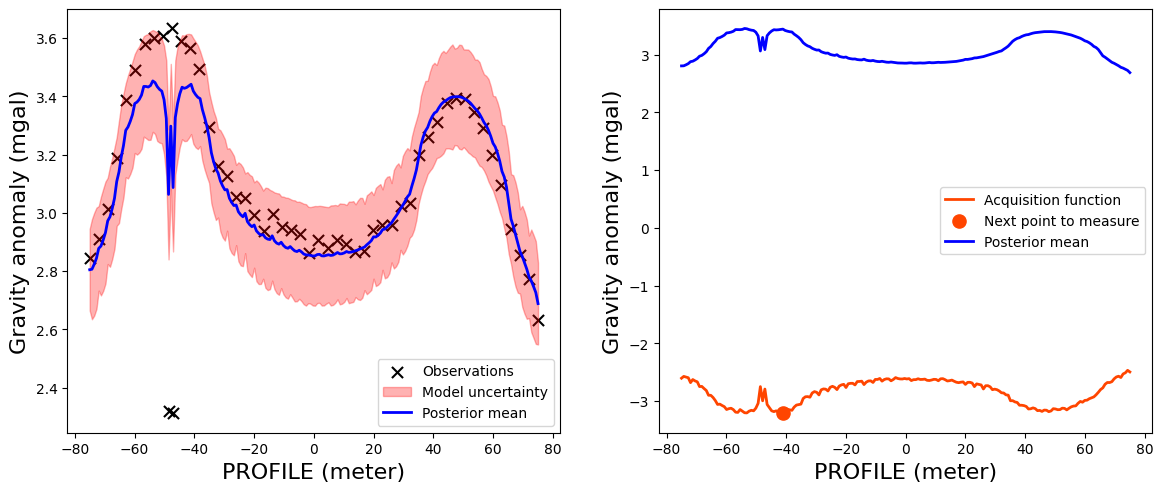


Exploration step 4


sample: 100%|██████████| 2500/2500 [00:48<00:00, 51.10it/s, 31 steps of size 1.10e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.43      0.16      0.44      0.19      0.69    263.24      1.00
       B_D2      0.57      0.19      0.58      0.31      0.90    289.09      1.02
  density_1      2.31      0.20      2.28      2.00      2.59    320.70      1.00
  density_2      2.31      0.22      2.27      2.00      2.61    289.41      1.00
k_length[0]      3.78      8.41      0.65      0.04     10.35    150.26      1.00
    k_scale      0.05      0.04      0.04      0.01      0.09    258.19      1.00
      noise      0.08      0.03      0.08      0.04      0.12    233.74      1.00

44.84924623115579
1.91541585579135


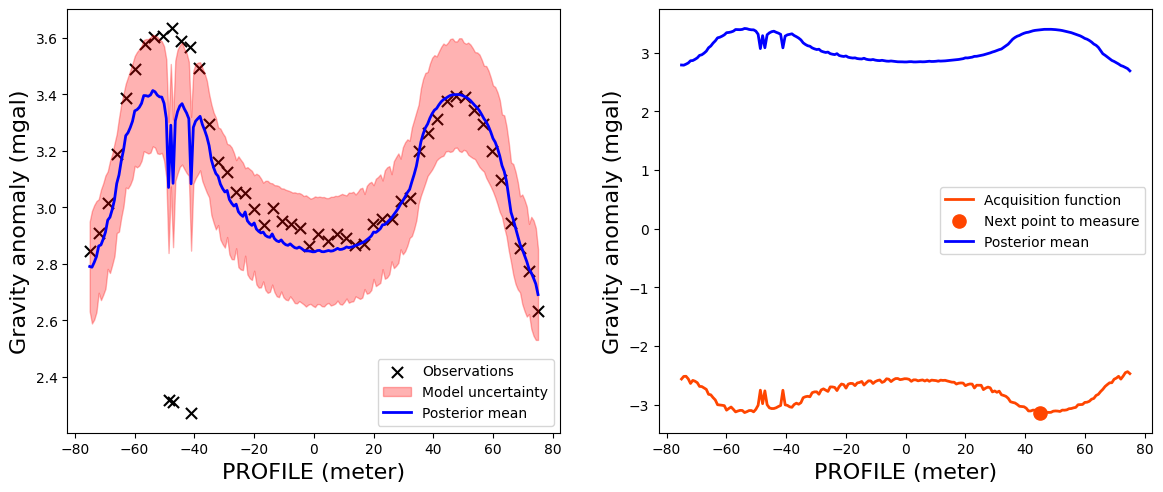


Exploration step 5


sample: 100%|██████████| 2500/2500 [00:49<00:00, 50.01it/s, 31 steps of size 1.34e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.42      0.16      0.42      0.19      0.69    292.36      1.00
       B_D2      0.56      0.19      0.57      0.21      0.82    203.64      1.00
  density_1      2.36      0.22      2.34      2.01      2.69    162.68      1.00
  density_2      2.26      0.21      2.21      2.00      2.57    272.08      1.02
k_length[0]      2.39      5.44      0.34      0.03      6.67    135.94      1.01
    k_scale      0.07      0.06      0.06      0.02      0.12    279.56      1.00
      noise      0.11      0.04      0.11      0.04      0.16    173.47      1.00

-50.879396984924625
2.3197821002486783


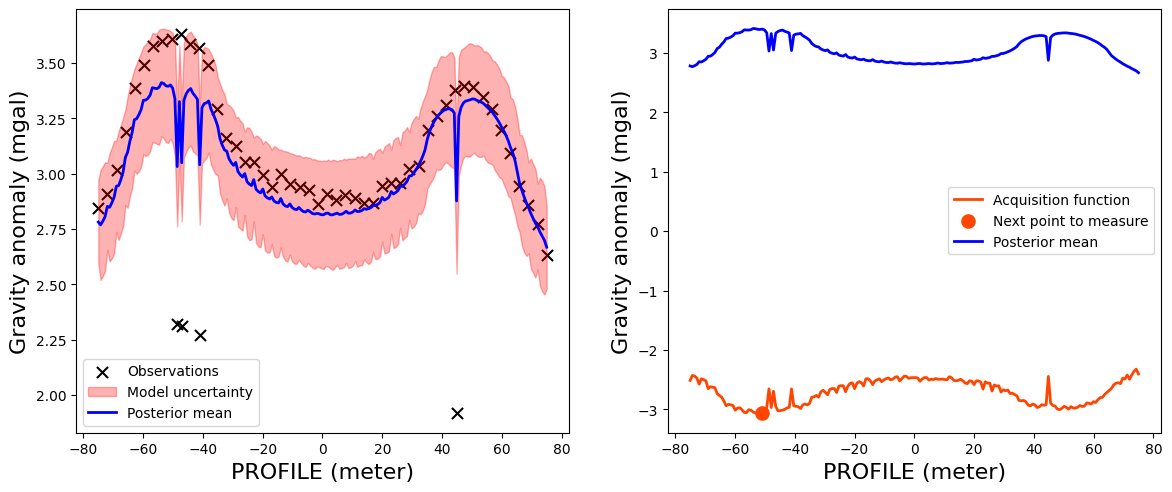


Exploration step 6


sample: 100%|██████████| 2500/2500 [00:48<00:00, 51.84it/s, 31 steps of size 1.28e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.42      0.16      0.42      0.17      0.65    338.69      1.00
       B_D2      0.55      0.19      0.55      0.22      0.83    328.83      1.02
  density_1      2.32      0.21      2.28      2.03      2.63    269.29      1.02
  density_2      2.30      0.23      2.24      2.00      2.63    351.11      1.02
k_length[0]      3.44      6.85      0.45      0.02     10.51    157.15      1.01
    k_scale      0.08      0.05      0.07      0.01      0.13    204.47      1.00
      noise      0.12      0.04      0.12      0.04      0.18    180.05      1.00

-53.89447236180904
2.2738556473737686


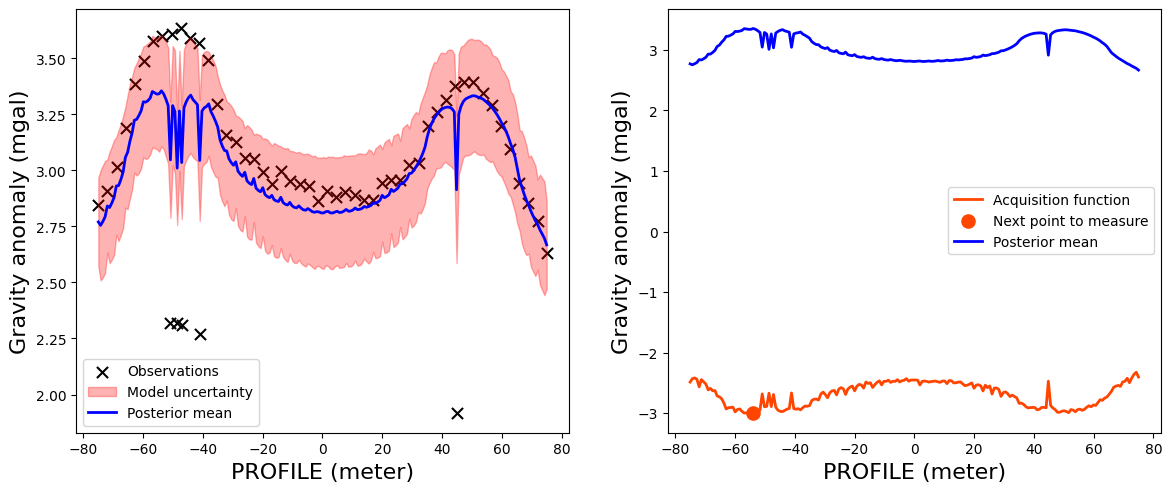


Exploration step 7


sample: 100%|██████████| 2500/2500 [00:45<00:00, 54.80it/s, 31 steps of size 1.67e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.40      0.16      0.40      0.12      0.63    227.91      1.01
       B_D2      0.55      0.19      0.55      0.26      0.86    217.39      1.00
  density_1      2.30      0.22      2.27      2.00      2.63    353.78      1.00
  density_2      2.32      0.24      2.28      2.00      2.69    251.77      1.01
k_length[0]      5.90      8.35      1.92      0.04     16.77    101.94      1.02
    k_scale      0.10      0.09      0.07      0.01      0.18    119.53      1.04
      noise      0.15      0.05      0.15      0.07      0.22    161.97      1.01

51.63316582914574
1.9163598653577876


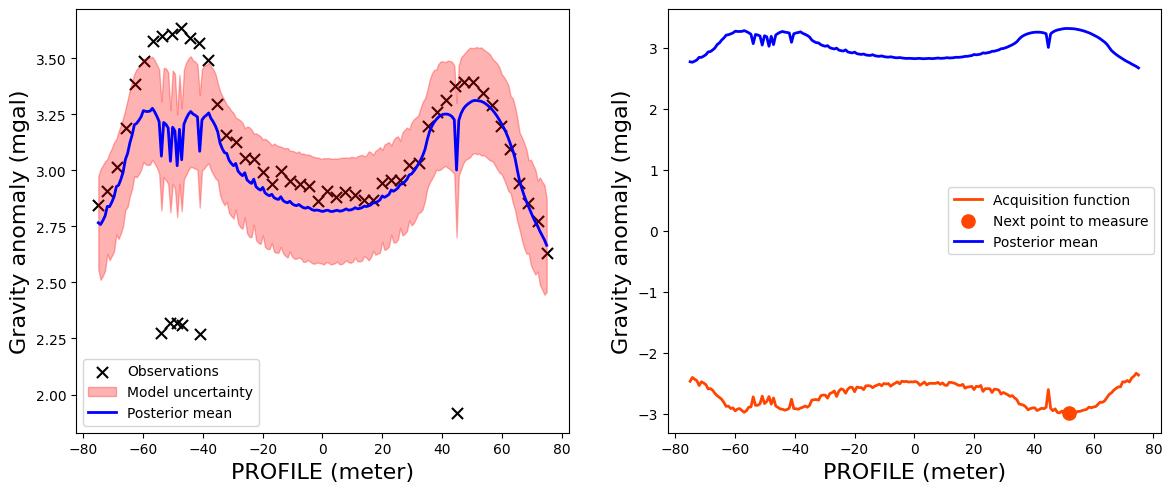


Exploration step 8


sample: 100%|██████████| 2500/2500 [00:47<00:00, 53.16it/s, 23 steps of size 1.64e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.39      0.17      0.39      0.15      0.66    217.00      1.00
       B_D2      0.56      0.19      0.56      0.28      0.88    355.36      1.00
  density_1      2.33      0.23      2.29      2.00      2.65    330.94      1.00
  density_2      2.27      0.22      2.21      2.00      2.59    276.18      1.01
k_length[0]      5.01      9.22      0.88      0.02     14.48    123.33      1.01
    k_scale      0.11      0.08      0.09      0.02      0.20    146.02      1.02
      noise      0.17      0.06      0.17      0.07      0.25    172.21      1.00

-57.663316582914575
2.21581517650155


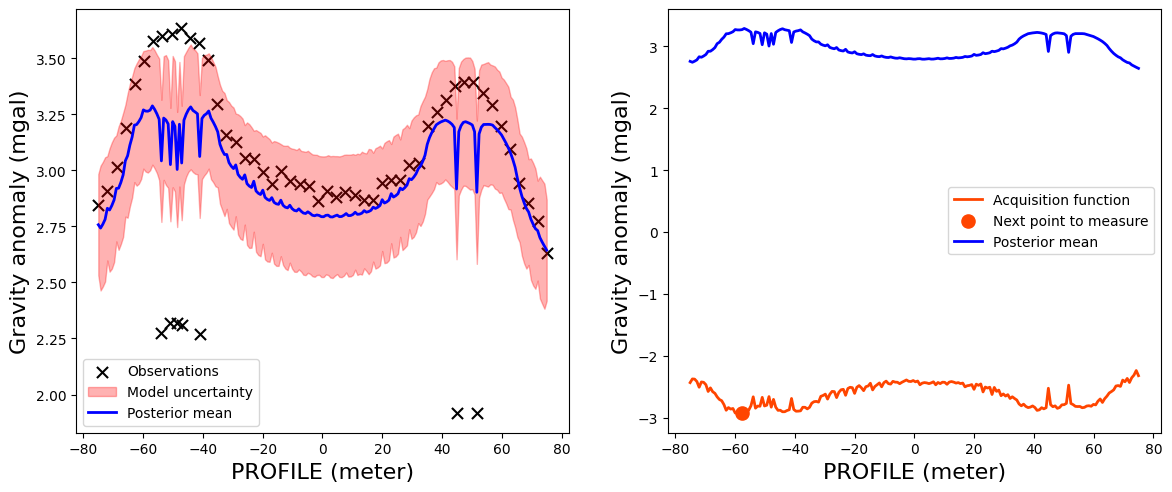


Exploration step 9


sample: 100%|██████████| 2500/2500 [00:48<00:00, 51.04it/s, 15 steps of size 1.90e-01. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.39      0.17      0.38      0.11      0.64    275.09      1.00
       B_D2      0.53      0.19      0.53      0.26      0.86    300.98      1.00
  density_1      2.32      0.23      2.28      2.01      2.68    245.47      1.00
  density_2      2.32      0.23      2.27      2.00      2.68    216.56      1.01
k_length[0]      4.57      7.95      0.52      0.02     14.82     59.45      1.07
    k_scale      0.13      0.11      0.10      0.02      0.24    165.15      1.03
      noise      0.17      0.06      0.17      0.08      0.28    150.04      1.03

-42.58793969849246
2.271510349337453


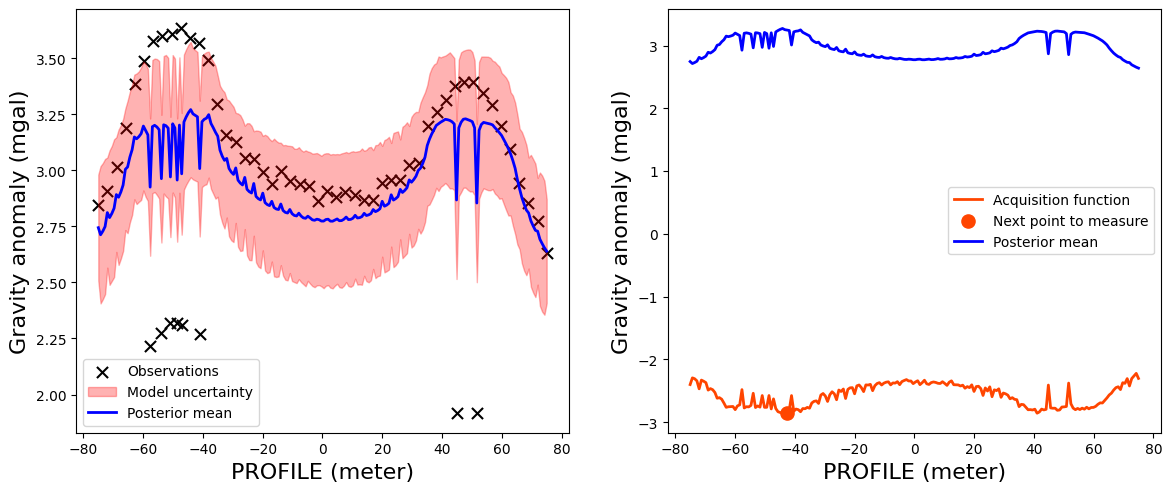


Exploration step 10


sample: 100%|██████████| 2500/2500 [00:55<00:00, 44.94it/s, 7 steps of size 1.78e-01. acc. prob=0.89] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.38      0.17      0.37      0.14      0.67    240.69      1.00
       B_D2      0.54      0.19      0.53      0.21      0.81    302.67      1.00
  density_1      2.29      0.22      2.25      2.00      2.60    210.79      1.00
  density_2      2.33      0.24      2.28      2.00      2.67    250.31      1.01
k_length[0]      5.83      8.60      0.98      0.03     17.27    121.54      1.01
    k_scale      0.12      0.10      0.10      0.02      0.20    172.95      1.03
      noise      0.19      0.07      0.19      0.09      0.31    179.00      1.00

41.83417085427136
1.8940586878611838


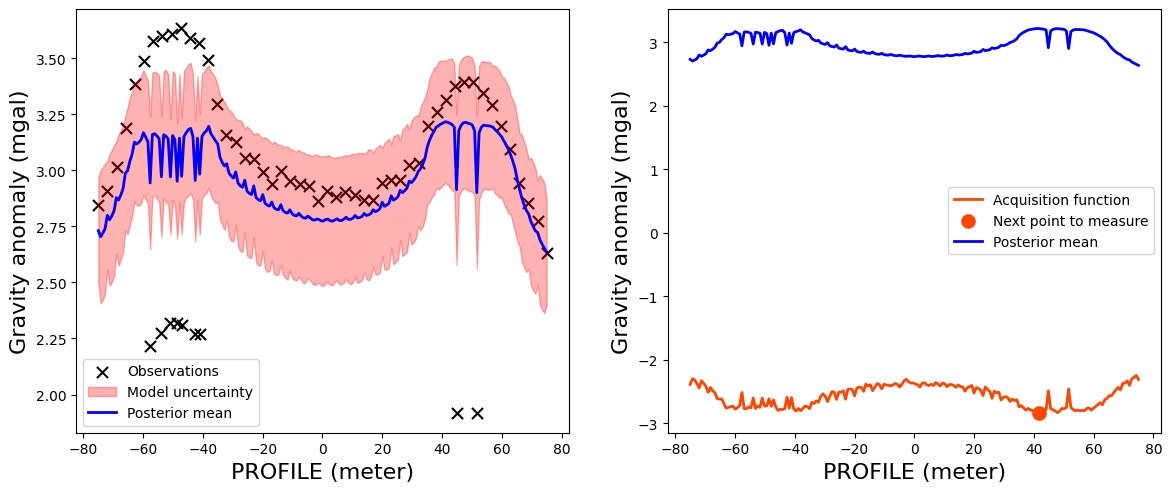

In [ ]:

# Copy the initial observations so that we can re-use them later
Xo, yo = X.copy(), y.copy()

rng_key, rng_key_predict = gpax.utils.get_keys(1)

for i in range(10):
    print("\nExploration step {}".format(i+1))

    # Obtain/update GP posterior
    gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=Bayes_1_Inf, mean_fn_prior=Bayes_1_Inf_prior)
    gp_model.fit(rng_key, Xo, yo, num_warmup = 2000, num_samples = 500, num_chains = 1, print_summary=1)

    #Upper confidence bound
    obj = gpax.acquisition.UCB(rng_key_predict, gp_model, X_test, beta= 2, maximize=False, noiseless=True)

    #Expected improvement
    #obj = gpax.acquisition.EI(rng_key_predict, gp_model, X_test, xi=0.01, maximize=False, n=10, noiseless=True) #xi = 0.01

    next_point_idx = obj.argmin()

     # Append the 'suggested' point
    Xo = np.append(Xo, X_test[next_point_idx])
    print(Xo[-1])
    measured = Bayes_1_Inf(X_test[next_point_idx], PARAMS) + np.random.normal(0., 0.01)  # we assume that new observations are also noisy
    yo = np.append(yo, measured)
    print(yo[-1])

    # Plot observed points, mean prediction, and acqusition function
    y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, noiseless=True, n= 10)

    lower_b = y_pred - y_sampled.std(axis=(0,1))
    upper_b = y_pred + y_sampled.std(axis=(0,1))

    fig, (ax1, ax2) = plt.subplots(1, 2, dpi=100, figsize=(14, 5.5))
    ax1.scatter(Xo[:-1], yo[:-1], marker='x', c='k', label="Observations", s=64)
    ax1.fill_between(X_test, lower_b, upper_b, color='r', alpha=0.3, label="Model uncertainty")
    ax2.plot(X_test, obj, lw=2, c='orangered', label='Acquisition function')
    ax2.scatter(X_test[next_point_idx], obj[next_point_idx], s=90, c='orangered', label='Next point to measure')
    for ax in fig.axes:
        ax.plot(X_test, y_pred, lw=2, c='b', label='Posterior mean')
        ax.set_xlabel("PROFILE (meter)", fontsize=16)
        ax.set_ylabel("Gravity anomaly (mgal)", fontsize=16)
        ax.legend(loc='best', fontsize=10)
    plt.show()


In [ ]:
#Making prediction using all the newly discovered points:
rng_key, rng_key_predict = gpax.utils.get_keys(1)

# Update GP posterior
gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=Bayes_1_Inf, mean_fn_prior=Bayes_1_Inf_prior)
gp_model.fit(rng_key, Xo, yo, num_warmup = 2000, num_samples = 100, num_chains = 1)

# Get GP prediction
y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, n=200)

sample: 100%|██████████| 2100/2100 [00:38<00:00, 54.54it/s, 15 steps of size 1.56e-01. acc. prob=0.95]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.35      0.18      0.32      0.09      0.63     68.43      1.00
       B_D2      0.52      0.20      0.52      0.20      0.82     56.91      1.01
  density_1      2.37      0.25      2.33      2.02      2.79     96.64      0.99
  density_2      2.36      0.26      2.33      2.02      2.79     65.09      0.99
k_length[0]      6.33      6.71      4.39      0.08     16.88     22.52      0.99
    k_scale      0.12      0.08      0.10      0.04      0.21     59.70      0.99
      noise      0.22      0.07      0.22      0.10      0.32     67.71      1.00



In [ ]:
#Collecting inverted model parameters
params4 = gp_model.get_samples()
params4.keys()

import warnings
warnings.filterwarnings("ignore")

# Plot results

plt.tight_layout(pad=2)
plt.figure(figsize=(10, 7))
plt.subplot(211)
#X_Seed=np.asarray(list(set(Xo).symmetric_difference(set(X))))
#y_Seed=measure_func(X_Seed)
#y_Seed= np.asarray(list(set(yo).symmetric_difference(set(y))))
#plt.scatter(X_Seed, y_Seed,marker="D",label="New Discovered points", zorder=1)
#plt.scatter(X_Seed, y_Seed, c=jnp.arange(1, len(X_Seed)+1),
            #cmap='viridis', label="New Discovered points", zorder=1)
#plt.scatter(Xo[50:], yo[50:],marker="D",label="New Discovered points", zorder=1)
plt.scatter(Xo[50:], yo[50:], c=jnp.arange(1, len(Xo[50:])+1),
            cmap='viridis', label="Sampled points", zorder=1)
cbar = plt.colorbar(label="Exploration Step")
cbar_ticks = np.arange(1, len(X_Seed) + 1, 1)
#cbar_ticks = np.arange(1, len(Xo[50:]) + 1, 1)
cbar.set_ticks(cbar_ticks)

plt.scatter(X, y, marker='x', s=64,
            c='k', label="Noisy Observations", zorder=1)
#plt.plot(X_test, truefunc, c='k', label='True function', zorder=0)
plt.plot(X_test, y_pred, '--', c='red', label='Model Reconstruction', zorder=0) #model reconstructions

plt.fill_between(X_test, y_pred - y_sampled.std((0,1)), y_pred + y_sampled.std((0,1)),
                        color='r', alpha=0.2, label="Model Uncertainty", zorder=0) #model uncertainty

#plt.xlabel("X", fontsize=12)
plt.ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
plt.legend()
legend_properties = {'weight':'bold','size':'7'}
plt.legend(prop=legend_properties)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.tick_params(labelbottom=False)
plt.ylim(2.6,4.3)
#plt.show() # Remove this line to avoid creating a new figure


cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3#maximum density value in color scale in gm/cc
minimum_V=2#minimum density value in color scale in gm/cc
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)
#choosing the color depending upon the inverted density value of 1st prism
index_value_V1 = (params4['density_1'].mean()-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
#choosing the color depending upon the inverted density value of 2nd prism
index_value_V2 = (params4['density_2'].mean()-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)


plt.subplot(212) # Select the second subplot in the existing figure
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
# plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,3),label='Density(gm/cc)')
# Use the current axes (axs[1]) for the colorbar
plt.colorbar(sm, ax=plt.gca(), ticks=np.linspace(minimum_V, maximum_V, 3), label='Density(gm/cc)') # Changed line

#creating a prism using 4 corner co-ordinates using inverted results
coord1 = [[-65,0], [-35,0], [-35,params4['B_D1'].mean()], [-65,params4['B_D1'].mean()]]
coord2 = [[35,0], [65,0], [65,params4['B_D2'].mean()], [35, params4['B_D2'].mean()]]
coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
xs1, ys1 = zip(*coord1) #create lists of x and y values
xs2, ys2 = zip(*coord2) #create lists of x and y values
#creating a prism using 4 corner co-ordinates using real values
coord3 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
coord4 = [[35,0], [65,0], [65,0.5], [35,0.5]]
coord3.append(coord3[0]) #repeat the first point to create a 'closed loop'
coord4.append(coord4[0]) #repeat the first point to create a 'closed loop'
xs3, ys3 = zip(*coord3) #create lists of x and y values
xs4, ys4 = zip(*coord4) #create lists of x and y values
plt.plot(xs3,ys3,'red',linestyle='dashed')#plotting prism1 using real values
plt.plot(xs1,ys1,'k')#plotting prism1 using inverted values
plt.fill(xs1, ys1, facecolor=color_V1)#color filling inverted prism1 with inverted density value of prism 1
plt.plot(xs4,ys4,'red',linestyle='dashed')#plotting prism2 using real values
plt.plot(xs2,ys2,'k')#plotting prism2 using inverted values
plt.fill(xs2, ys2, facecolor=color_V2)#color filling inverted prism1 with inverted density value of prism 2
plt.xlim(-80,80)
plt.ylim(1,0)
legend_properties = {'weight':'bold','size':'7'}
plt.legend(['Real Boundary','Inverted Boundary'],prop=legend_properties)
plt.xlabel('<<-- Profile (meter)-->>',fontsize=10,weight='bold')
plt.ylabel("<<--Depth (km)",fontsize=10,weight='bold')
#axs[1].set_xticks(weight='bold')
plt.xticks(weight= 'bold')
plt.yticks(weight= 'bold')
plt.show()
